In [1]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent

import pandas as pd

# pd.set_option('display.max_columns', None)  # none은 제한값 자리(몇개 열까지 보여줄까)
# pd.set_option('display.max_rows', None)

# ============================================================
# 1. 데이터 불러오기
# ============================================================

train = pd.read_parquet(PROJECT_ROOT / 'parqueted_data' / 'train_split.parquet')
val = pd.read_parquet(PROJECT_ROOT / 'parqueted_data' / 'val_split.parquet')

In [ ]:
# ============================================================
# 2. 컬럼 분리
# ============================================================

# 시계열 컬럼군
time_cols = [
    'wl_t',          # 수위데이터 대표
    'sfc_rain_1h',   # 육상 누적강수데이터 대표
    'imerg_rain_1h', # 레이더 누적강수데이터 대표
    'radar_reflectivity_mean', # 레이더반사도 대표
    'radar_reflectivity_p95', # 레이더반사도 대표
    'target_maxrise_6h' # 종속변수: 수위상승량
]

# 수위 컬럼군
wl_cols_EDA = [
    'wl_t',
    'wl_t_minus_1h',
    'wl_t_minus_3h',
    'wl_t_minus_6h',
    'wl_t_minus_12h',
    'wl_t_minus_24h',
    'target_maxrise_6h',
]

# 강수 컬럼군
rain_cols = [
    # IMERG강우
    'imerg_rain_1h',
    'imerg_rain_6h',
    'imerg_rain_24h',
    # 지상강우
    'sfc_rain_1h',
    'sfc_rain_6h',
    'sfc_rain_24h',
    # 레이더 반사도
    'radar_reflectivity_mean',
    'radar_reflectivity_p95',
    'radar_reflectivity_ge20_fraction'
]

# 환경 컬럼군
env_cols = [
    'cat_area',       # km²
    'wsarea',         # km²
    'mean_elevation', # m
    'mean_slope',     # °
    'urban_ratio',    # %
    'forest_ratio',   # %
    'stream_order'
]

print(len(wl_cols_EDA), len(rain_cols), len(env_cols))

7 9 7


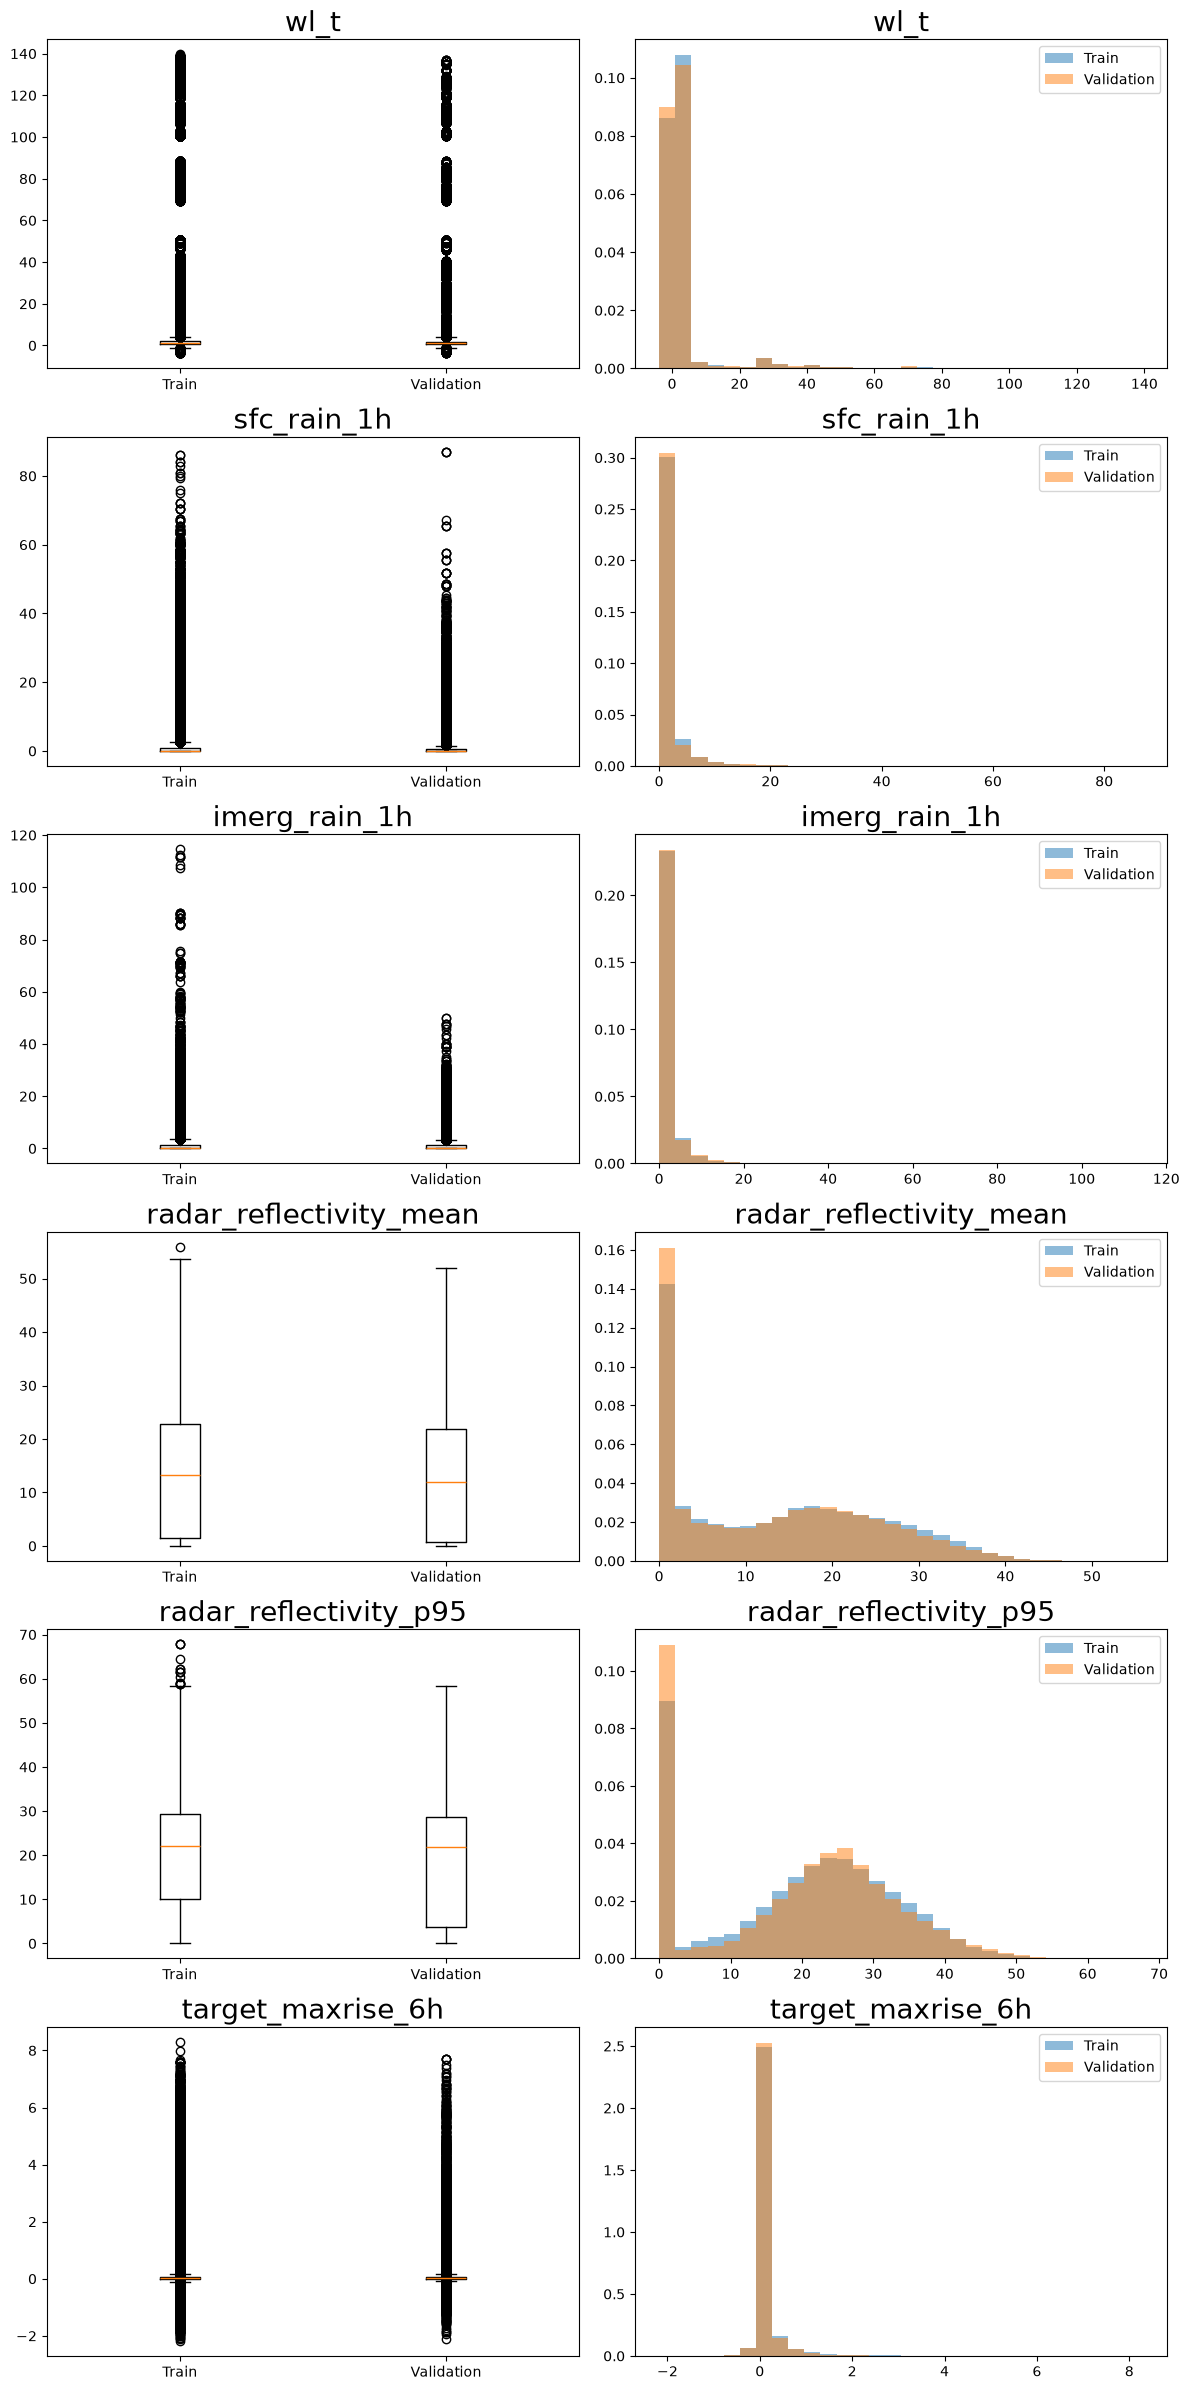

In [ ]:
# ======================================================================
# 3-1. (시계열) train, val 데이터 박스플롯, 히스토그램 비교하기: 분포 비교용
# ======================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(time_cols),
    2,
    figsize = (12, 4 * len(time_cols))
)

if len(time_cols) == 1 :
    axes = [axes]

for i, col in enumerate(time_cols):
    tr = train[col].dropna()
    va = val[col].dropna()

    axes[i][0].boxplot([tr, va], tick_labels = ['Train', 'Validation'])
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)
    # 박스플롯은 x축에 이름이 적히므로 범례 필요없음

    axes[i][1].hist(tr, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
                    # range로 범위를 통일하지 않으면, 서로다른 범위를 bin만큼 쪼개므로 범위가 달라 분포도 바뀜
                    bins = 30, alpha = 0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
                    density = True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
                    label = 'Train')
    axes[i][1].hist(va, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
                    bins = 30, alpha = 0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
                    density = True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
                    label = 'Validation')
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)
    axes[i][1].legend()  # 범례

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3-2. (시계열) 기초통계량 비교: 시계열데이터 전부 다 비교
# ============================================================

for col in (wl_cols_EDA + rain_cols):
    print(col)
    q = pd.concat(
        [
            train[col].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]).round(1),
            val[col].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]).round(1)
        ],
        axis = 1,  # 가로로 붙이기
        keys = ['Train', 'Validation']  # 시리즈는 columns가 아니라 keys로 명명
    )

    q['val/train_ratio'] = (q['Validation'] / q['Train']).round(1)
    
    print(q.to_csv(sep = '\t'))  # 탭으로 구분된 csv로 변환

    print()


wl_t
	Train	Validation	val/train_ratio
0.5	1.1	1.1	1.0
0.75	2.0	1.9	1.0
0.9	4.0	3.7	0.9
0.95	25.0	25.0	1.0
0.99	78.8	79.3	1.0
1.0	139.6	136.8	1.0


wl_t_minus_1h
	Train	Validation	val/train_ratio
0.5	1.1	1.1	1.0
0.75	2.0	1.9	1.0
0.9	4.0	3.7	0.9
0.95	25.0	25.0	1.0
0.99	78.8	79.3	1.0
1.0	139.7	136.8	1.0


wl_t_minus_3h
	Train	Validation	val/train_ratio
0.5	1.1	1.1	1.0
0.75	2.0	1.9	1.0
0.9	3.9	3.7	0.9
0.95	25.0	25.0	1.0
0.99	78.8	79.3	1.0
1.0	139.8	136.7	1.0


wl_t_minus_6h
	Train	Validation	val/train_ratio
0.5	1.1	1.1	1.0
0.75	1.9	1.9	1.0
0.9	3.9	3.7	0.9
0.95	25.0	25.0	1.0
0.99	78.8	79.3	1.0
1.0	139.9	136.6	1.0


wl_t_minus_12h
	Train	Validation	val/train_ratio
0.5	1.1	1.1	1.0
0.75	1.9	1.9	1.0
0.9	3.8	3.8	1.0
0.95	25.0	25.0	1.0
0.99	78.8	79.2	1.0
1.0	140.1	136.4	1.0


wl_t_minus_24h
	Train	Validation	val/train_ratio
0.5	1.1	1.1	1.0
0.75	1.9	1.9	1.0
0.9	3.8	3.8	1.0
0.95	25.0	25.0	1.0
0.99	78.8	79.2	1.0
1.0	140.6	135.5	1.0


target_maxrise_6h
	Train	Validation	val/train_ratio
0.5	0.0	0.0	


In [ ]:
# imerg_rain_24h, sfc_rain_24h에서 상위 분위값에서 train, val간 차이 확인
# 두 변수는 더 공정한 비교(강우사상 지속기간 차이에 따른 영향을 배제)를 위해 1개 값으로 요약하여 비교
# (강우사상별 기간이 달라 데이터 개수도 다름, 긴 강우사상이 더 영향을 주므로 사상별 1개값으로 요약)

for col in ['imerg_rain_24h', 'sfc_rain_24h']:
    print(col + '(event_id_groupby)')
    q = pd.concat(
        [
            train.groupby('event_id')[col]
            .max()
            .quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]).round(1),
            val.groupby('event_id')[col].max()
            .quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]).round(1)
        ],
        axis = 1,
        keys = ['Train', 'Validation']
    )
    
    q['val/train_ratio'] = (q['Validation'] / q['Train']).round(1)

    print(q.to_csv(sep='\t'))
    print()

imerg_rain_24h(event_id_groupby)
	Train	Validation	val/train_ratio
0.5	43.6	63.7	1.5
0.75	79.7	109.3	1.4
0.9	129.2	141.2	1.1
0.95	172.9	154.0	0.9
0.99	362.9	160.3	0.4
1.0	371.2	161.7	0.4


sfc_rain_24h(event_id_groupby)
	Train	Validation	val/train_ratio
0.5	44.0	50.5	1.1
0.75	99.8	113.2	1.1
0.9	172.0	175.4	1.0
0.95	203.2	186.6	0.9
0.99	364.8	216.6	0.6
1.0	390.0	225.0	0.6




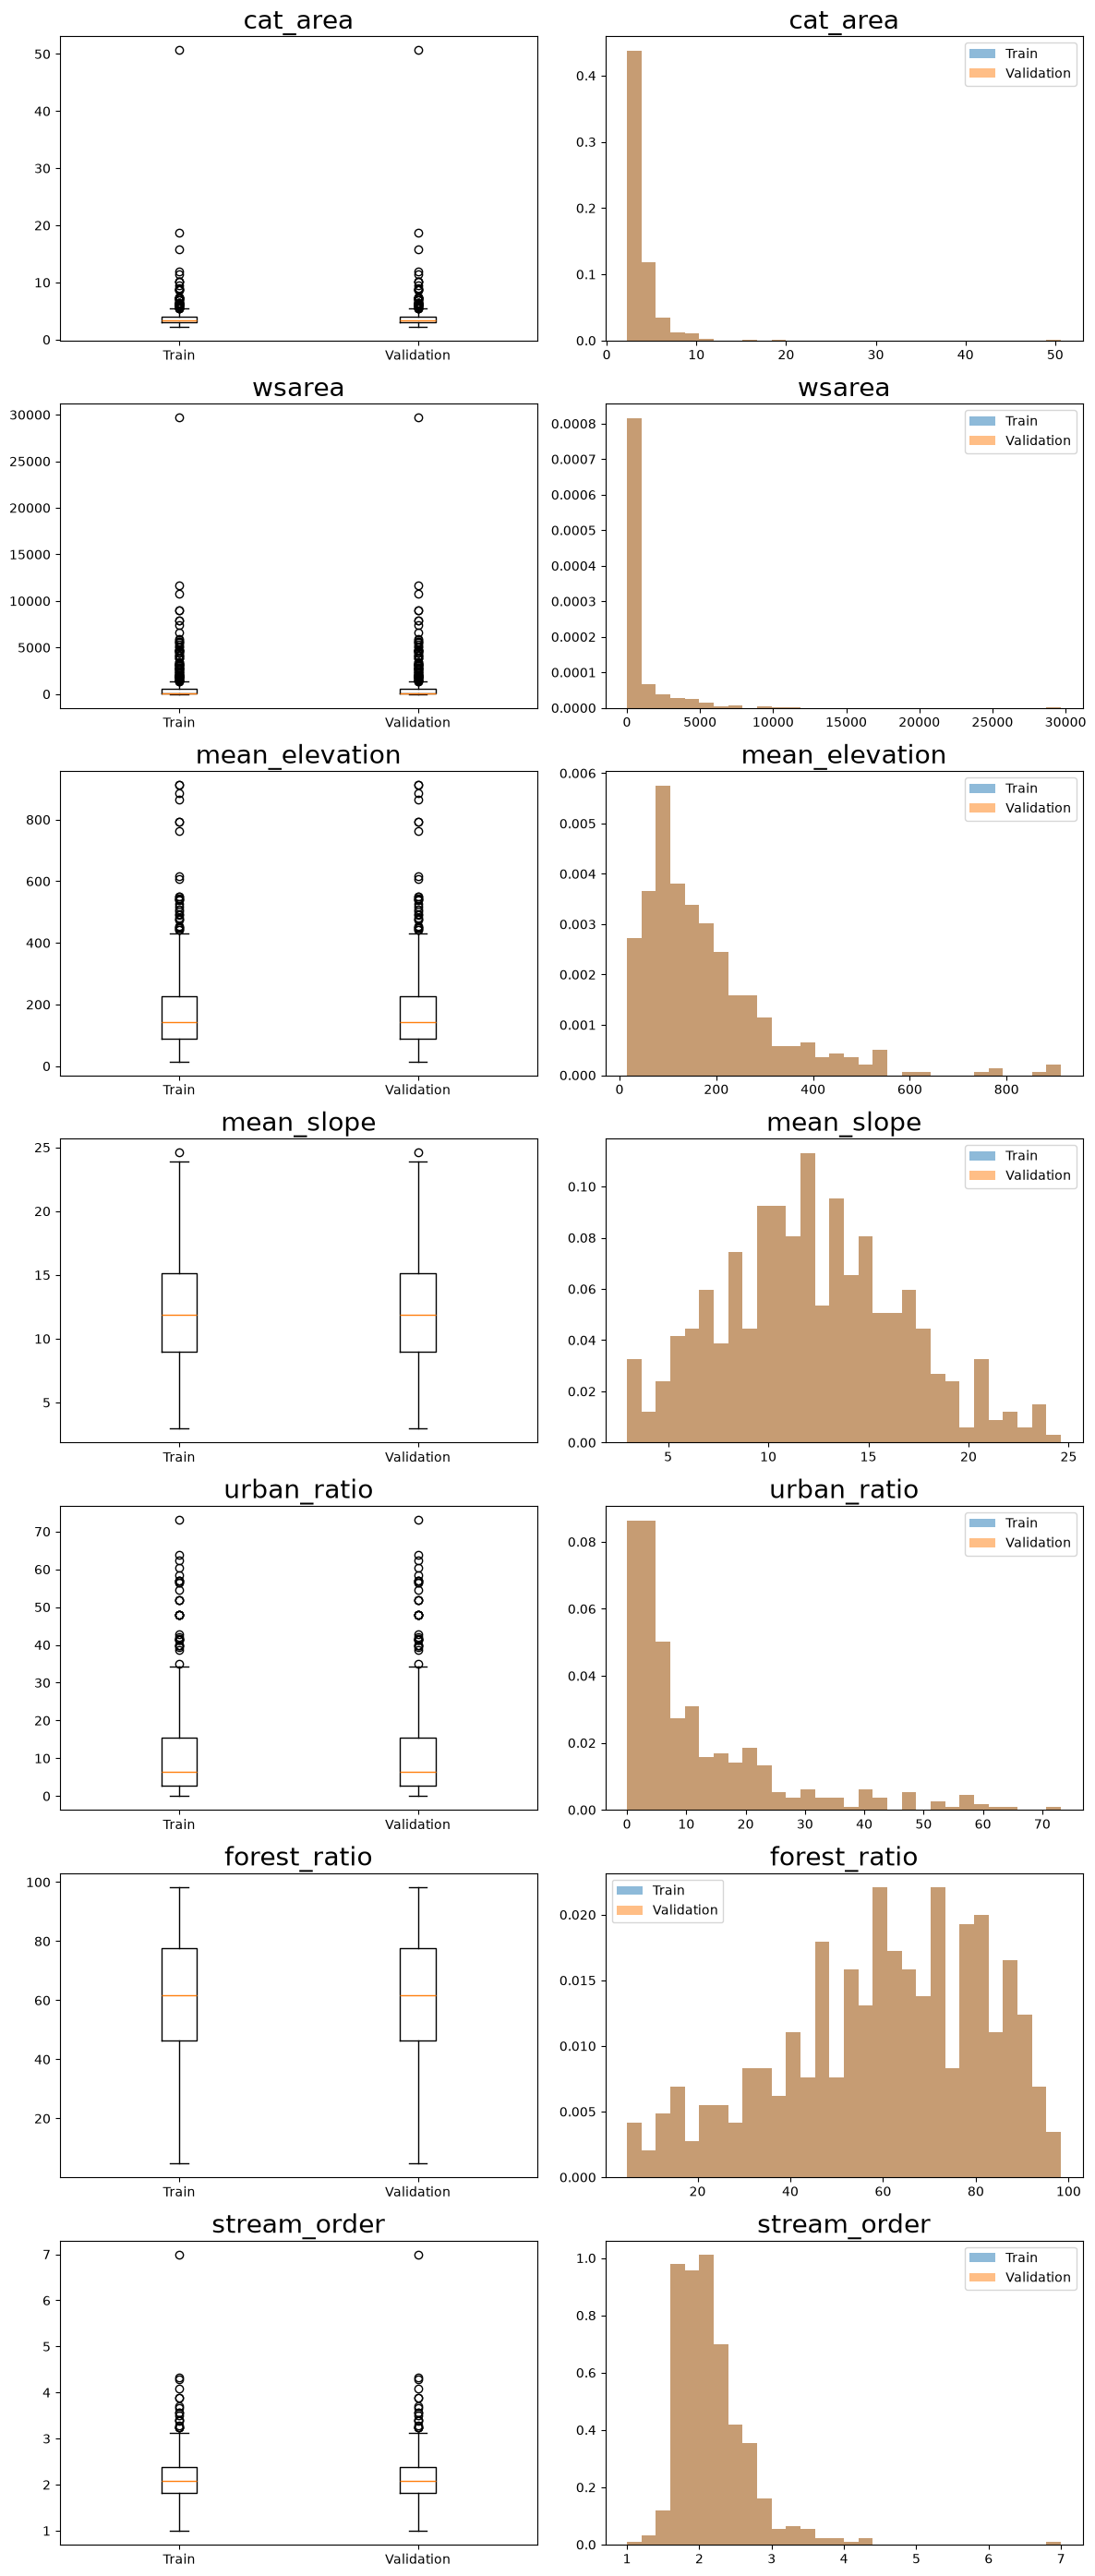

In [ ]:
# =========================================================================
# 4-1. (환경데이터) train, val 데이터 박스플롯, 히스토그램 비교하기: 분포 비교용
# =========================================================================
# 환경데이터는 관측소별로 groupby 한 후에 박스플롯과 히스토그램 그리기
# 시간사상별로 분할, 관측소는 동일하므로 동일한 분포를 가짐

train_env_gb_df = train.groupby('station_id')[env_cols].first()
val_env_gb_df = val.groupby('station_id')[env_cols].first()

# display(train_env_gb_df)
# display(val_env_gb_df)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(env_cols),
    2,
    figsize = (12, 4 * len(env_cols))
)

if len(time_cols) == 1 :
    axes = [axes]

for i, col in enumerate(env_cols):
    tr = train_env_gb_df[col].dropna()
    va = val_env_gb_df[col].dropna()

    axes[i][0].boxplot([tr, va], tick_labels = ['Train', 'Validation'])
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)
    # 박스플롯은 x축에 이름이 적히므로 범례 필요없음

    axes[i][1].hist(
        tr, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
        # range로 범위를 통일하지 않으면, 서로다른 범위를 bin만큼 쪼개므로 범위가 달라 분포도 바뀜
        bins=30, 
        alpha=0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
        density=True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
        label='Train'
    )
    axes[i][1].hist(
        va, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
        bins=30, 
        alpha=0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
        density=True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
        label='Validation'
    )
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)
    axes[i][1].legend()  # 범례

plt.tight_layout()
plt.show()

In [16]:
# env_cols는 train, val이 똑같아 보임
# 시간(event_id) 기준으로 분할을 했고, 관측소는 동일하다했으니 당연한 결과로 판단됨
# 혹시몰라서 확인

print(train_env_gb_df.shape)
print(val_env_gb_df.shape)

print(
    len(
        set(train_env_gb_df.index)  # set(): 집합으로 만들기
        & set(val_env_gb_df.index)  # &: 교집합
    )  # 결과: train, val의 환경데이터 관측소 번호(groupby 기준열 = 인덱스)가 같다.
)
# groupby를 쓰면 기준열이 인덱스로 올라간다.

(465, 7)
(465, 7)
465
